# MFCC-based Speaker Recognition CNN dataset generation

This notebook is in charge of the following:


# MFCC-based Speaker Recognition CNN dataset generation

This notebook is in charge of the following:

* ~~Downloading the selected SNR NBFM dataset to extract the IQ samples~~ (Assumed to be provided)
* Generate the Mel-Frequency Cepstral Coefficients (MFFC's)
* Prepare the dataset for training, validation and testing





## Dataset Download

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa
import pickle
import numpy as np
import os

import json

random_seed = 55
rng = np.random.default_rng(random_seed)
tf.random.set_seed(random_seed)

In [9]:
# Dataset path
base_path = f"Dataset_76db"

subfolders = sorted(os.listdir(base_path))  # ['f0001', 'f0002', ...]
print(f"Subfolders: {subfolders}")

# Verify files in f0001
files = os.listdir(f"{base_path}/f0001")
print(f"Files in f0001: {len(files)}")

# Load as binary complex64 data
print("---- File import example ----")
filepath = f"{base_path}/f0001/last3_f0001_us_f0001_00001_fm.iq"
raw_data = np.fromfile(filepath, dtype=np.complex64)
real_part = np.real(raw_data)
imag_part = np.imag(raw_data)

# Create file tags
# Lists to store paths and labels
file_paths = []
labels = []

# Run over all folders
for class_idx, folder in enumerate(subfolders):
    folder_path = os.path.join(base_path, folder)
    files = os.listdir(folder_path)

    # Save files and folder indexes
    for file in files:
        file_paths.append(os.path.join(folder_path, file))
        labels.append(class_idx)  # 0 para f0001, 1 para f0002, etc.

# Convert to numpy arrays
file_paths = np.array(file_paths)
labels = np.array(labels)

# Verification
print("Files:", len(file_paths))
print("Example:", file_paths[3282], "-> Label:", labels[3282]," label dtype: ",labels[3282].dtype,"\n")
print(f"Filepaths\n", file_paths,"\n")
print(f"Labels\n",labels, " Unique labels: ", np.unique(labels))

Subfolders: ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']
Files in f0001: 283
---- File import example ----
Files: 3283
Example: Dataset_76db/m0005/last3_m0005_us_m0005_00223_fm.iq -> Label: 9  label dtype:  int64 

Filepaths
 ['Dataset_76db/f0001/last3_f0001_us_f0001_00272_fm.iq'
 'Dataset_76db/f0001/last3_f0001_us_f0001_00258_fm.iq'
 'Dataset_76db/f0001/last3_f0001_us_f0001_00151_fm.iq' ...
 'Dataset_76db/m0005/last3_m0005_us_m0005_00153_fm.iq'
 'Dataset_76db/m0005/last3_m0005_us_m0005_00085_fm.iq'
 'Dataset_76db/m0005/last3_m0005_us_m0005_00223_fm.iq'] 

Labels
 [0 0 0 ... 9 9 9]  Unique labels:  [0 1 2 3 4 5 6 7 8 9]


In [ ]:
def _load_iq_py(path_bytes):
    path = path_bytes.numpy().decode('utf-8')
    iq = np.fromfile(path, dtype=np.complex64)
    arr = np.stack([np.real(iq), np.imag(iq)], axis=-1).astype(np.float32)

    # Normalization
    eps = 1e-7  # Avoid division by zero
    iq_mean = arr.mean(axis=0, keepdims=True)
    iq_std = arr.std(axis=0, keepdims=True) + eps

    return ((arr - iq_mean) / iq_std).astype(np.float32)


def load_py(path, y):
    iq_wave = tf.py_function(_load_iq_py, [path], Tout=tf.float32)
    iq_wave.set_shape([None, 2])  # Expected shape: (samples, 2)
    return iq_wave, tf.cast(y, tf.int32)

# Create dataset from filepaths and labels
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

# Shuffle dataset
dataset = dataset.shuffle(buffer_size=len(file_paths), reshuffle_each_iteration=True)

# Map the dataset with the generator function
dataset = dataset.map(load_py, num_parallel_calls=tf.data.AUTOTUNE)

# Verification -> Dataset must be a tensor of dimension (samples, 2)
for iq, label in dataset.take(3):  # Take 3 examples
    print(f"IQ shape: {iq.shape}, Label: {label.numpy()}")

iq_sample, _ = dataset.take(1).as_numpy_iterator().next()

num_samples = iq_sample.shape[0]
num_channels = iq_sample.shape[1]
print(f"Sample shape: {iq_sample.shape} -> Num samples: {num_samples}, Num channels: {num_channels}")

IQ shape: (144000, 2), Label: 6
IQ shape: (144000, 2), Label: 6
IQ shape: (144000, 2), Label: 3
Sample shape: (144000, 2) -> Num samples: 144000, Num channels: 2


## MFFCs feature extraction


MFCC shape: (20, 64, 2)  (esperado: (20, 64, 2))


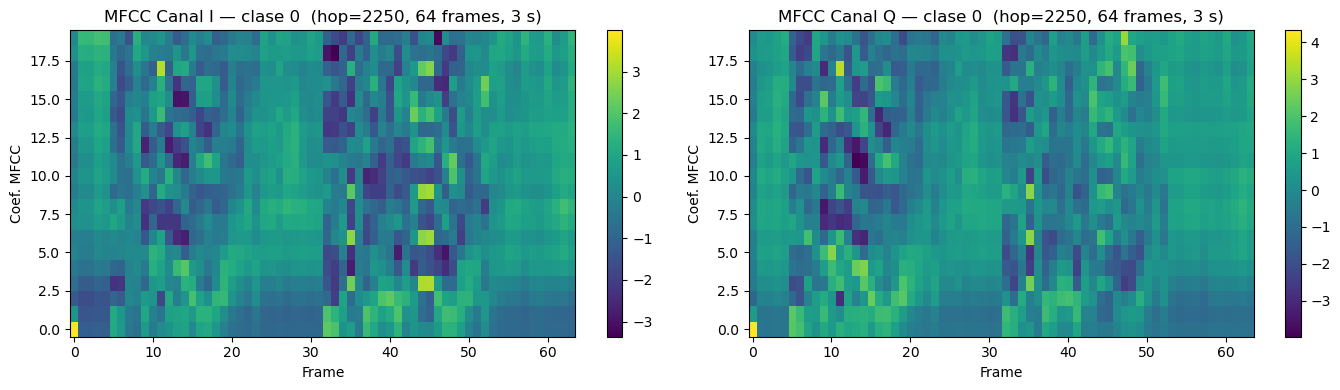

MFCC shape: (20, 64, 2)  (esperado: (20, 64, 2))


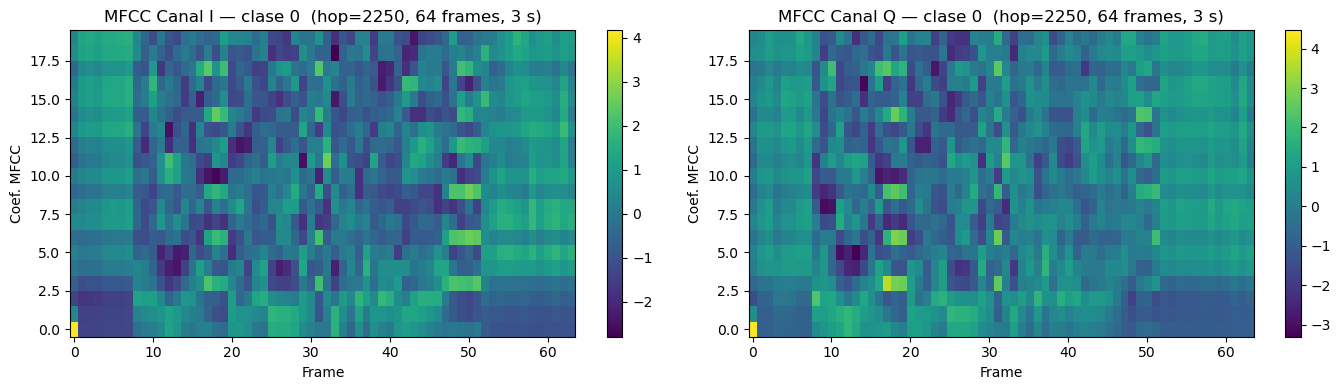

MFCC shape: (20, 64, 2)  (esperado: (20, 64, 2))


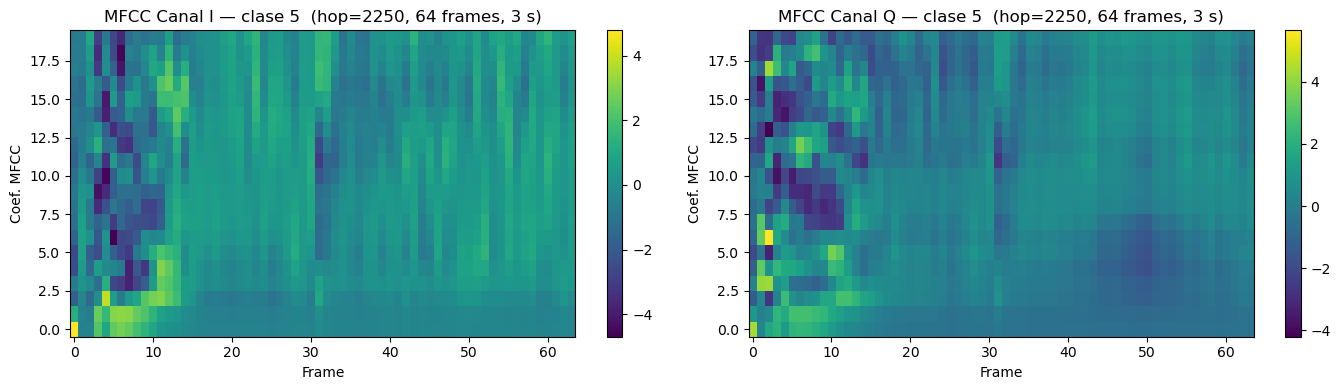

In [ ]:
# ── MFCC Parameters — BRAM-Opt configuration ─────────────────────────────────
# hop_length = 2250  →  144 000 samples / 2250 = 64 exact frames
# Covers the full 3 s of the .iq file WITHOUT discarding signal.
# librosa validity: hop_length (2250) ≥ n_fft/2 (1024)  ✓
#
# Impact on BRAM_18K with io_stream:
#   original  (hop=512,  frames=282): FIFO depth=20×282=5 640 → ~681 BRAM (236 %)
#   BRAM-Opt  (hop=2250, frames=64) : FIFO depth=20×64 =1 280 → ~120 BRAM ( 42 %)
# ─────────────────────────────────────────────────────────────────────────────
SAMPLING_FREQ = 48000   # Hz
N_MFCC        = 20      # MFCC coefficients
N_FFT         = 2048    # FFT window (42.7 ms @ 48 kHz)
HOP_LENGTH    = 2250    # samples/frame  →  64 frames cover 3 s
MFCC_FRAMES   = 64      # target frames (fixed)


def extract_mfcc_from_iq_channels(iq_tensor, label):
    """
    Extract MFCCs from the I and Q channels of an IQ tensor and stack them
    into a 2-channel input (N_MFCC, MFCC_FRAMES, 2) for the CNN.

    Key parameters:
      hop_length = 2250  →  64 frames cover the full 3 s of the .iq file
      The signal is NOT truncated; it is processed in full.
    """
    def _extract_mfcc_py(signal_tensor):
        import librosa
        import numpy as np
        signal_np = signal_tensor.numpy()
        mfccs = librosa.feature.mfcc(
            y=signal_np,
            sr=SAMPLING_FREQ,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
        )
        # Adjust to exactly MFCC_FRAMES columns
        if mfccs.shape[1] < MFCC_FRAMES:
            mfccs = np.pad(mfccs, ((0, 0), (0, MFCC_FRAMES - mfccs.shape[1])), mode='edge')
        else:
            mfccs = mfccs[:, :MFCC_FRAMES]
        # Normalization by coefficient (mean=0, std=1 across frames)
        mu  = mfccs.mean(axis=1, keepdims=True)
        std = mfccs.std(axis=1,  keepdims=True) + 1e-8
        return ((mfccs - mu) / std).astype(np.float32)

    mfcc_i = tf.py_function(_extract_mfcc_py, [iq_tensor[:, 0]], Tout=tf.float32)
    mfcc_q = tf.py_function(_extract_mfcc_py, [iq_tensor[:, 1]], Tout=tf.float32)

    mfccs_stacked = tf.stack([mfcc_i, mfcc_q], axis=-1)   # (N_MFCC, MFCC_FRAMES, 2)
    mfccs_stacked.set_shape([N_MFCC, MFCC_FRAMES, 2])
    return mfccs_stacked, label


# Apply MFCC extraction to the dataset
MFCC_dataset = dataset.map(extract_mfcc_from_iq_channels, num_parallel_calls=tf.data.AUTOTUNE)

# Verify shape and visualize
for example_mfcc, label in MFCC_dataset.take(3):
    MFCC_input_shape = example_mfcc.shape
    print(f'MFCC shape: {MFCC_input_shape}  (expected: ({N_MFCC}, {MFCC_FRAMES}, 2))')

    mfcc_i_ch = example_mfcc[:, :, 0].numpy()
    mfcc_q_ch = example_mfcc[:, :, 1].numpy()

    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    for ax, data, ch in zip(axs, [mfcc_i_ch, mfcc_q_ch], ['I', 'Q']):
        im = ax.imshow(data, aspect='auto', origin='lower', cmap='viridis')
        fig.colorbar(im, ax=ax)
        ax.set_title(f'MFCC Canal {ch} — clase {label.numpy()}  '
                     f'(hop={HOP_LENGTH}, {MFCC_FRAMES} frames, 3 s)')
        ax.set_xlabel('Frame'); ax.set_ylabel('Coef. MFCC')
    plt.tight_layout(); plt.show()


## MFCCs Dataset split

In [ ]:
# Split dataset into train, validation, and test sets
test_dataset_ratio = 0.15
validation_dataset_ratio = 0.15

dataset_size = len(MFCC_dataset)
train_dataset_size = int(dataset_size * (1 - test_dataset_ratio - validation_dataset_ratio))
validation_dataset_size = int(dataset_size * validation_dataset_ratio)

MFCC_dataset_design = MFCC_dataset.take(train_dataset_size + validation_dataset_size)
MFCC_dataset_test = MFCC_dataset.skip(train_dataset_size + validation_dataset_size)

MFCC_dataset_train = MFCC_dataset_design.take(train_dataset_size)
MFCC_dataset_validation = MFCC_dataset_design.skip(train_dataset_size)

# Verify the size of each dataset
print(f"Train dataset size: {MFCC_dataset_train.cardinality().numpy()}")
print(f"Validation dataset size: {MFCC_dataset_validation.cardinality().numpy()}")
print(f"Test dataset size: {MFCC_dataset_test.cardinality().numpy()}")

# Prepare batches
batch_size = 32
MFCC_dataset_train_batches = MFCC_dataset_train.batch(batch_size).prefetch(tf.data.AUTOTUNE)
MFCC_dataset_validation_batches = MFCC_dataset_validation.batch(batch_size).prefetch(tf.data.AUTOTUNE)
MFCC_dataset_test_batches = MFCC_dataset_test.batch(batch_size).prefetch(tf.data.AUTOTUNE)

for data_batch, y_batch in MFCC_dataset_train_batches.take(1):
  print(f"Data batch shape: {data_batch.shape}")
  print(f"Labels batch shape: {y_batch.shape}")

# Verify number of batches
windows_per_batch = len(MFCC_dataset_train_batches)
print(f"Windows per batch: {windows_per_batch}")

Train dataset size: 2298
Validation dataset size: 492
Test dataset size: 493
Data batch shape: (32, 20, 64, 2)
Labels batch shape: (32,)
Windows per batch: 72


## Dataset Export

Saves the three batched dataset splits and a `metadata.json` to `MFCC_datasets/` so the training notebook can start directly from pre-generated features.

> **Suggestion:** The pickled `element_spec.pkl` already allows reloading the TF datasets. Adding `metadata.json` alongside it lets the training notebook restore model-critical parameters (`MFCC_input_shape`, `num_classes`, etc.) without re-running any data generation step.

In [ ]:
output_dir = "MFCC_datasets"
os.makedirs(output_dir, exist_ok=True)

# ── Save batched datasets ───────────────────────────────────────────────
train_path = os.path.join(output_dir, "train_batches")
val_path   = os.path.join(output_dir, "validation_batches")
test_path  = os.path.join(output_dir, "test_batches")

MFCC_dataset_train_batches.save(train_path)
MFCC_dataset_validation_batches.save(val_path)
MFCC_dataset_test_batches.save(test_path)

# ── Save element specs (needed to reload TF datasets) ──────────
specs = {
    "train":      MFCC_dataset_train_batches.element_spec,
    "validation": MFCC_dataset_validation_batches.element_spec,
    "test":       MFCC_dataset_test_batches.element_spec,
}
with open(os.path.join(output_dir, "element_spec.pkl"), "wb") as f:
    pickle.dump(specs, f)

# ── Save model parameters to metadata.json ────────────────────────────
dataset_metadata = {
    "MFCC_input_shape": list(MFCC_input_shape),
    "num_classes":      int(len(np.unique(labels))),
    "N_MFCC":           int(N_MFCC),
    "MFCC_FRAMES":      int(MFCC_FRAMES),
    "HOP_LENGTH":       int(HOP_LENGTH),
    "N_FFT":            int(N_FFT),
    "SAMPLING_FREQ":    int(SAMPLING_FREQ),
    "batch_size":       int(batch_size),
    "subfolders":       list(subfolders),
    "labels":           np.unique(labels).tolist(),
}
with open(os.path.join(output_dir, "metadata.json"), "w") as f:
    json.dump(dataset_metadata, f, indent=2)

print(f"Datasets saved in '{output_dir}/'")
print(f"  Train      : {train_path}")
print(f"  Validation : {val_path}")
print(f"  Test       : {test_path}")
print(f"  Spec       : {output_dir}/element_spec.pkl")
print(f"  Metadata   : {output_dir}/metadata.json")
print(f"\nMetadata written: {dataset_metadata}")


Datasets guardados en 'MFCC_datasets/'
  Train      : MFCC_datasets/train_batches
  Validation : MFCC_datasets/validation_batches
  Test       : MFCC_datasets/test_batches
  Spec       : MFCC_datasets/element_spec.pkl
  Metadata   : MFCC_datasets/metadata.json

Metadata escrita: {'MFCC_input_shape': [20, 64, 2], 'num_classes': 10, 'N_MFCC': 20, 'MFCC_FRAMES': 64, 'HOP_LENGTH': 2250, 'N_FFT': 2048, 'SAMPLING_FREQ': 48000, 'batch_size': 32, 'subfolders': ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005'], 'labels': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}
